In [1]:
import pandas as pd
import os
import json
import pickle
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from collections import defaultdict

# load ss-shock

In [2]:
DIR = "/lfs/local/0/serinac/supply-chains/TGB/tgb/datasets/tgbl_hypergraph_synthetic_shocks"
edgelist = "tgbl-hypergraph_synthetic_shocks_edgelist.csv"
metajson = "tgbl-hypergraph_synthetic_shocks_meta.json"

shock_data = pd.read_csv(os.path.join(DIR, edgelist))
print(shock_data.shape)
shock_data.head()

(56381, 5)


,ts,source,target,product,weight
0,2,23,6,119,18.0
1,2,5,17,122,80.0
2,2,4,43,121,74.0
3,2,23,19,122,56.0
4,2,19,43,122,74.0


In [3]:
with open("/lfs/local/0/serinac/supply-chains/synthetic_data/synthetic_data.pkl", 'rb') as f:
    prod_info = pickle.load(f)
    
num_firms = len(prod_info[0])
num_prods = len(prod_info[1])
prod_graph = prod_info[2]
prod_graph

,source,dest,units,layer
0,product1,product5,3,1
1,product4,product5,4,1
2,product0,product5,3,1
3,product3,product6,4,1
4,product0,product6,2,1
...,...,...,...,...
128,product37,product48,3,5
129,product42,product48,4,5
130,product37,product49,4,5
131,product43,product49,4,5


In [4]:
prod_info[2]

,source,dest,units,layer
0,product1,product5,3,1
1,product4,product5,4,1
2,product0,product5,3,1
3,product3,product6,4,1
4,product0,product6,2,1
...,...,...,...,...
128,product37,product48,3,5
129,product42,product48,4,5
130,product37,product49,4,5
131,product43,product49,4,5


# generate ground-truth labels
tracking how shocks trickle down

shocks happen to 
* product 0 at times 32 and 144
* product 2 at times 42 and 155
* product 3 at times 51, 90, and 144
* product 4 at times 16, 58, and 131

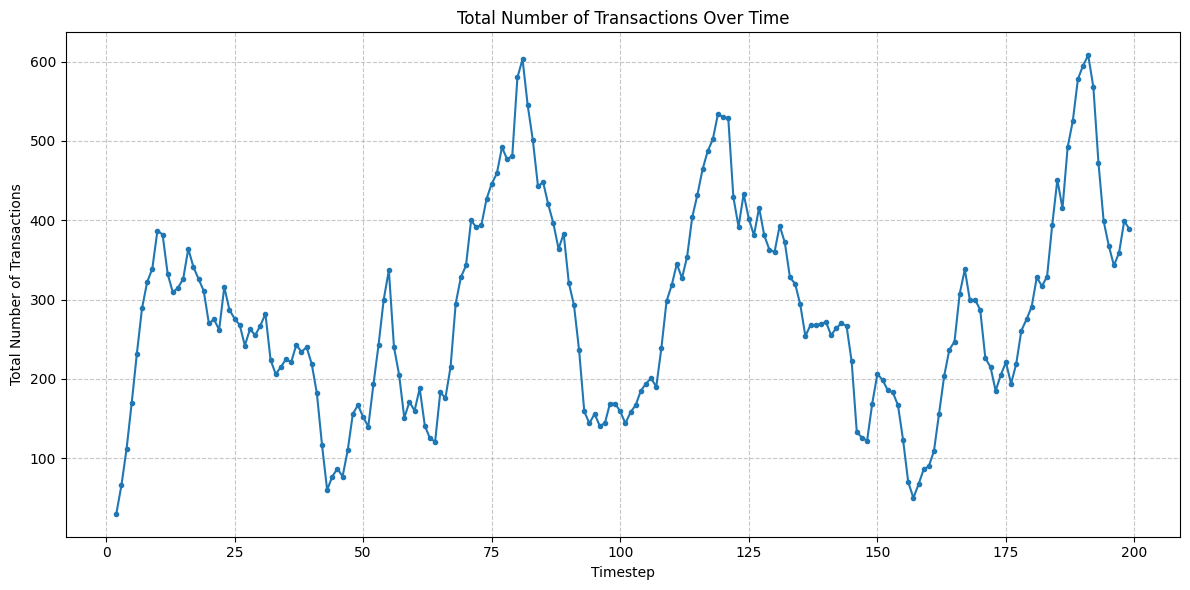

In [5]:
# Plot the total number of transactions over timesteps
def plot_transactions_over_time(data, timestep_col='ts', transaction_col='transaction_count', 
                                title='Total Number of Transactions Over Time'):
    """
    Plots the total number of transactions over time.
    
    Parameters:
        data (pd.DataFrame): The input dataset containing transaction data.
        timestep_col (str): The name of the column representing timesteps.
        transaction_col (str): The name of the column representing transaction counts.
        title (str): The title for the plot.
    """
    # Group by timestep and count the number of transactions
    transactions_per_timestep = data.groupby(timestep_col).size().reset_index(name=transaction_col)
    
    # Sort by timestep to ensure chronological order
    transactions_per_timestep = transactions_per_timestep.sort_values(timestep_col)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.plot(transactions_per_timestep[timestep_col], transactions_per_timestep[transaction_col], marker='.')
    
    # Customize the plot
    plt.title(title)
    plt.xlabel('Timestep')
    plt.ylabel('Total Number of Transactions')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

plot_transactions_over_time(shock_data)

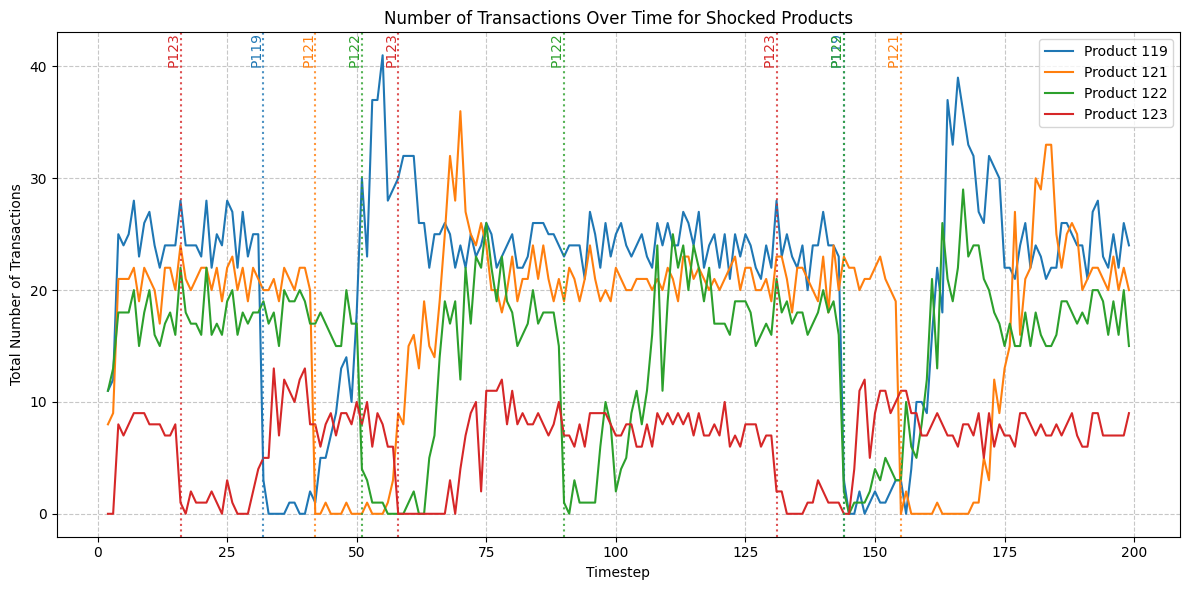

In [6]:
# Plot shocks on exogenous supply

# (given) shock times
shock_times = {
    119: [32, 144],
    121: [42, 155],
    122: [51, 90, 144],
    123: [16, 58, 131]
}

def plot_shocks_on_exogenous_supply(shock_data, shock_times, timestep_col='ts', product_col='product', 
                                   title='Number of Transactions Over Time for Shocked Products'):
    """
    Plots the number of transactions over time for shocked products and highlights shocks with vertical lines.
    
    Parameters:
        shock_data (pd.DataFrame): The dataset containing transaction data.
        shock_times (dict): A dictionary where keys are product IDs and values are lists of timesteps when shocks occurred.
        timestep_col (str): The name of the column representing timesteps in the dataset.
        product_col (str): The name of the column representing product IDs in the dataset.
    """
    # List of products that experience shocks
    shocked_products = shock_times.keys()

    # Group by timestep and product, then report number of transactions
    transactions_per_product = shock_data.groupby([timestep_col, product_col]).size().unstack(fill_value=0)

    # Filter for only the shocked products
    shocked_transactions = transactions_per_product[shocked_products]

    # Create the plot
    plt.figure(figsize=(12, 6))

    # Define a color map for the products
    colors = plt.cm.tab10.colors
    color_map = {product: colors[i % len(colors)] for i, product in enumerate(shocked_products)}

    # Plot each shocked product
    for product in shocked_products:
        plt.plot(shocked_transactions.index, shocked_transactions[product], 
                 label=f'Product {product}', color=color_map[product])

    # Customize the plot
    plt.title(title)
    plt.xlabel('Timestep')
    plt.ylabel('Total Number of Transactions')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight shock times with vertical lines and labels
    for product, times in shock_times.items():
        for time in times:
            plt.axvline(x=time, color=color_map[product], linestyle=':', alpha=0.8)
            plt.text(time, plt.ylim()[1], f'P{product}', rotation=90, va='top', ha='right', 
                     color=color_map[product])

    # Show the plot
    plt.tight_layout()
    plt.show()
plot_shocks_on_exogenous_supply(shock_data, shock_times)

Pause and think: 

Imagine a product chain p0 -> p1 -> p2 -> p3 -> p4. When exogeneous p0 drops, p1, p2, p3, p4 will all drop. Imagine two other production chains p1' -> p2 and p1' -> p2''. Because p1 drops and therefore p2 drops, we have increased p1' to use elsewhere, which causes p2'' to go up.
    
This will happen if initially # demand > # of supply. Keep this in mind if the data falls into this. SS-shock does not have this issue. 

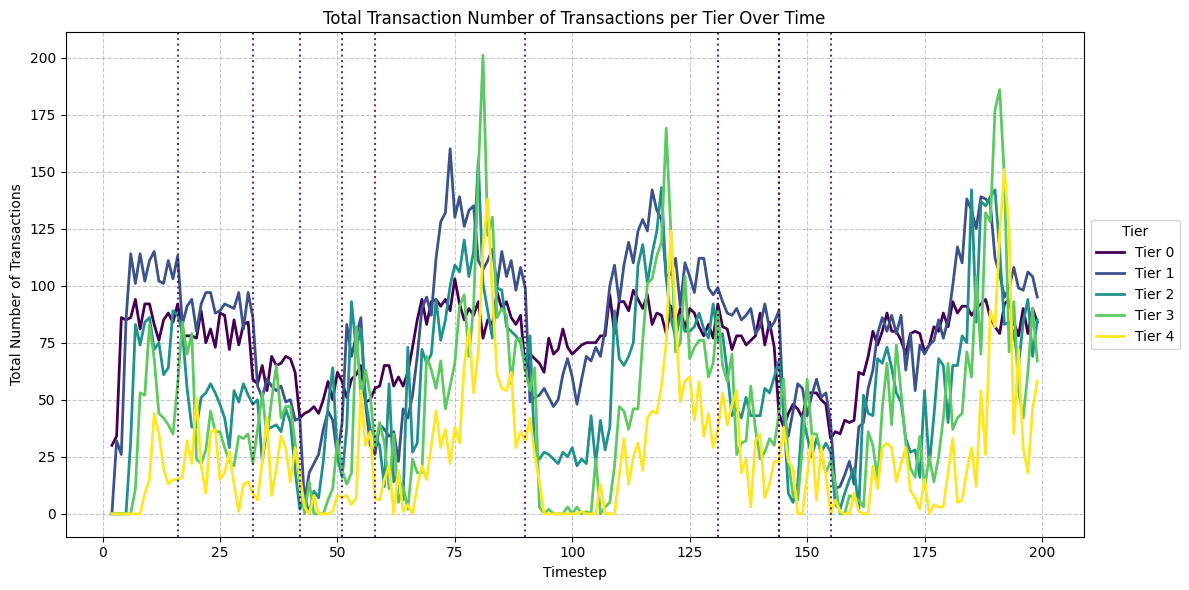

In [7]:
# plot number of transactions per tier

def get_product_tiers(products):
    """
    Assign tiers to products based on their index.
    First 5 products are tier 0, next 10 is tier 1, next 10 is tier 2,
    next 10 is tier 3, and last 5 is tier 4.
    """
    tiers = {}
    products = set(prod_graph['source'].unique()) | set(prod_graph['dest'].unique())
    for product in products:
        i = int(product.replace('product', ''))
        if i < 5:
            tiers[product] = 0
        elif i < 15:
            tiers[product] = 1
        elif i < 25:
            tiers[product] = 2
        elif i < 35:
            tiers[product] = 3
        else:
            tiers[product] = 4
    return tiers
     
def plot_transactions_per_tier(shock_data, prod_graph, shock_times, 
                               title='Total Transaction Number of Transactions per Tier Over Time', 
                               timestep_col='ts', product_col='product'):
    """
    Plots the total number of transactions per tier over time.

    Parameters:
        shock_data (pd.DataFrame): The dataset containing transaction data.
        prod_graph (pd.DataFrame): The product graph containing product relationships.
        shock_times (dict): A dictionary where keys are product IDs and values are lists of timesteps when shocks occurred.
        title (str): The title for the plot.
        timestep_col (str): The name of the column representing timesteps in the dataset.
        product_col (str): The name of the column representing product IDs in the dataset.
    """
    # Get product tiers
    product_tiers = get_product_tiers(prod_graph)

    # Create a mapping from product ID to tier
    PROD_OFFSET = 119
    product_id_to_tier = {int(prod_name.replace('product', '')) + PROD_OFFSET: tier 
                          for prod_name, tier in product_tiers.items()}

    # Add tier information to the shock_data
    shock_data['tier'] = shock_data[product_col].map(product_id_to_tier)

    # Group by time and tier, count the number of transactions
    transactions_per_tier = shock_data.groupby([timestep_col, 'tier']).size().unstack(fill_value=0)

    # Create the stacked area plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Get the viridis colormap
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(transactions_per_tier.columns)))

    # Plot each tier as a separate line
    for i, tier in enumerate(transactions_per_tier.columns):
        ax.plot(transactions_per_tier.index, transactions_per_tier[tier], 
                color=colors[i], label=f'Tier {tier}', linewidth=2)

    # Customize the plot
    ax.set_title(title)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Total Number of Transactions')
    ax.legend(title='Tier', loc='center left', bbox_to_anchor=(1, 0.5))

    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)

    # Plot shocks
    for product, times in shock_times.items():
        for time in times:
            plt.axvline(x=time, color=colors[0], linestyle=':', alpha=0.8)

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()
plot_transactions_per_tier(shock_data, prod_graph, shock_times)

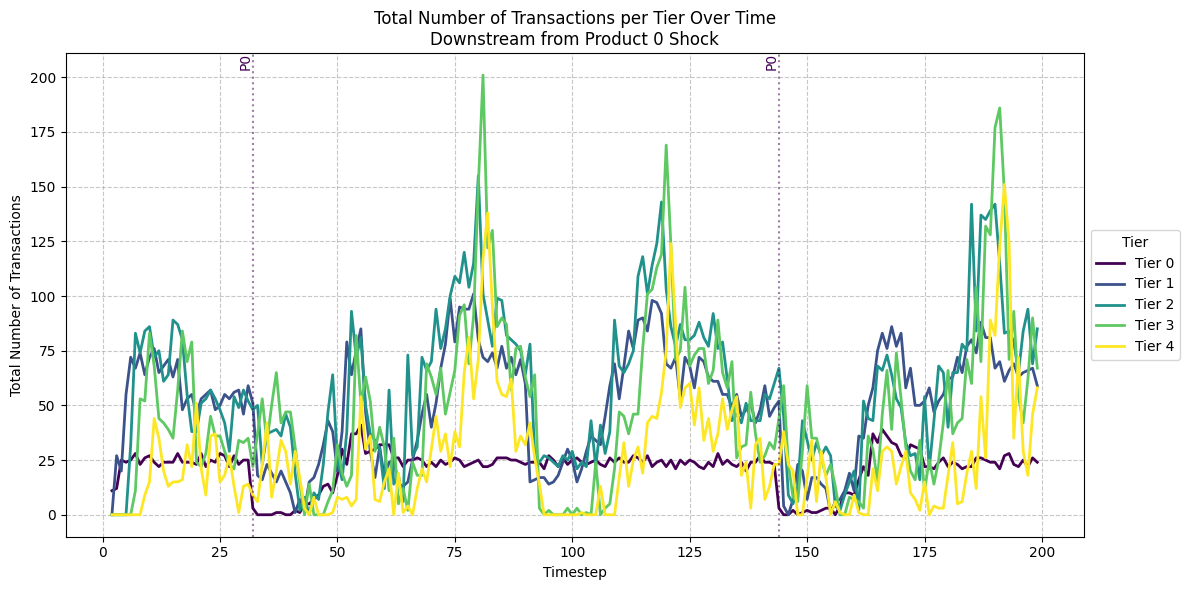

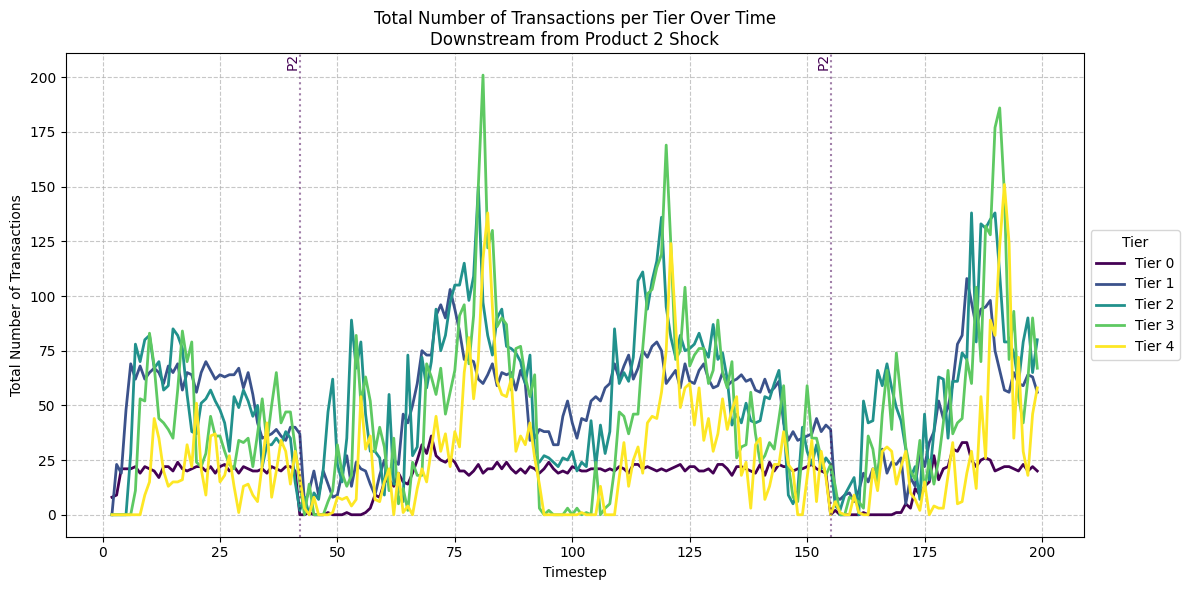

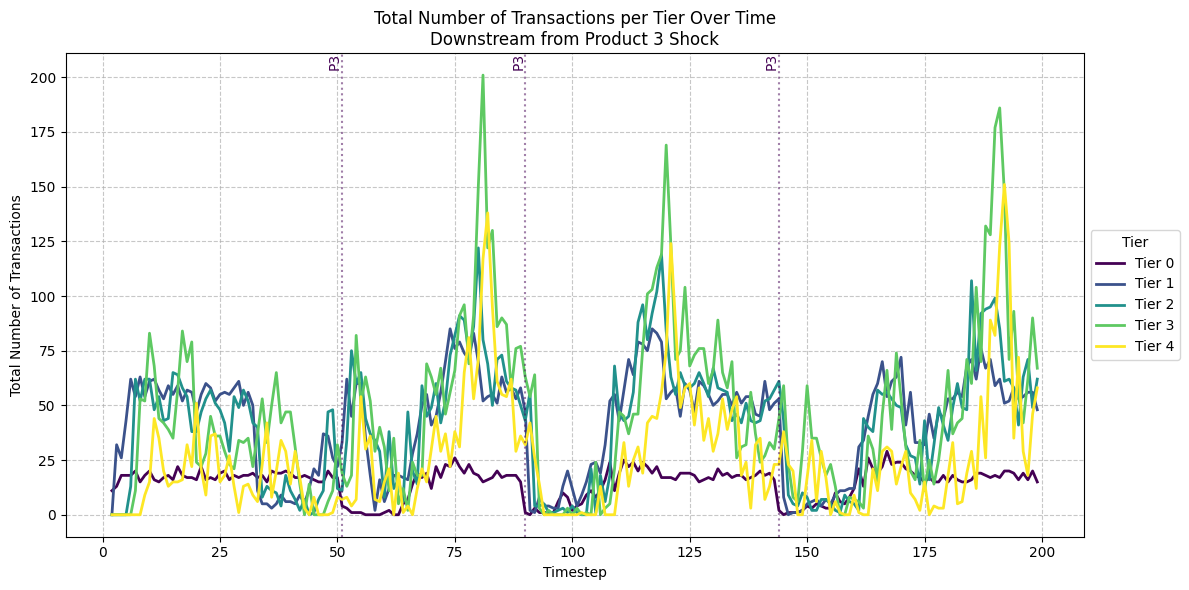

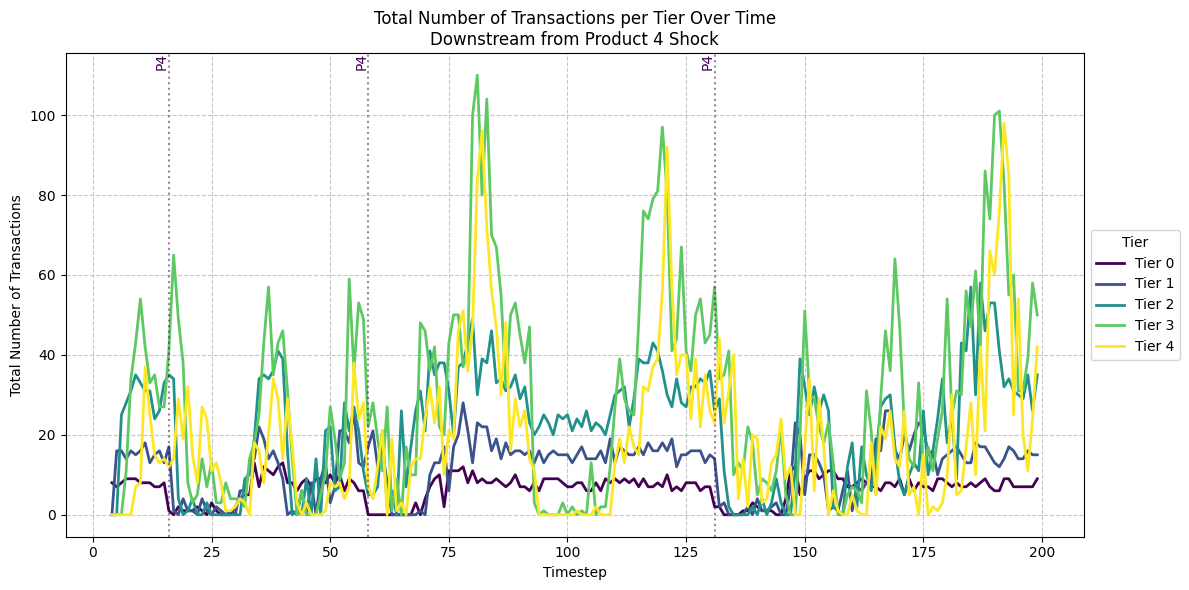

In [8]:
# Plot number of transactions per tier, per exogeneous supply and its downstream products 
def add_product_tiers(shock_data, prod_graph, PROD_OFFSET=119):
    # Get product tiers
    product_tiers = get_product_tiers(prod_graph)
    
    # Create a mapping from product ID to tier
    product_id_to_tier = {int(prod_name.replace('product', '')) + PROD_OFFSET: tier 
                          for prod_name, tier in product_tiers.items()}
    
    # Add tier information to the shock_data
    shock_data['tier'] = shock_data['product'].map(product_id_to_tier)

def get_downstream_products(prod_graph, start_product, max_tier):
    G = nx.DiGraph()
    for _, row in prod_graph.iterrows():
        G.add_edge(row['source'], row['dest'])
    
    downstream_products = set()
    current_tier = [start_product]
    for tier in range(max_tier + 1):
        next_tier = []
        for product in current_tier:
            downstream_products.add(product)
            next_tier.extend(list(G.successors(product)))
        current_tier = list(set(next_tier))
        if not current_tier:
            break
    return downstream_products

def plot_transactions_per_tier_perexogprod(shock_data, prod_graph, shock_times, exog_prod_ids, max_tier=4, PROD_OFFSET=119):
    for start_idx in exog_prod_ids:
        # Get downstream products for the first shock (product 0 at time 32)
        start_product = f'product{start_idx}'
        downstream_products = get_downstream_products(prod_graph, start_product, max_tier)
    
        # Filter shock_data for downstream products and the relevant time period
        relevant_products = [int(p.replace('product', '')) + PROD_OFFSET for p in downstream_products]
        relevant_time_start = 0  # First shock time
        relevant_time_end = 199    # Adjust this to show more or less time after the shock
        filtered_shock_data = shock_data[
            (shock_data['product'].isin(relevant_products)) & 
            (shock_data['ts'] >= relevant_time_start) & 
            (shock_data['ts'] <= relevant_time_end)
        ]
    
        # Group by time and tier, sum the number of transactions
        transactions_per_tier = filtered_shock_data.groupby(['ts', 'tier']).size().unstack(fill_value=0)
    
        # Create the plot
        fig, ax = plt.subplots(figsize=(12, 6))
    
        # Get the viridis colormap
        cmap = plt.get_cmap('viridis')
        colors = cmap(np.linspace(0, 1, len(transactions_per_tier.columns)))
    
        # Plot each tier as a separate line
        for i, tier in enumerate(transactions_per_tier.columns):
            ax.plot(transactions_per_tier.index, transactions_per_tier[tier], 
                    color=colors[i], label=f'Tier {tier}', linewidth=2)
    
        # Customize the plot
        ax.set_title(f'Total Number of Transactions per Tier Over Time\nDownstream from Product {start_idx} Shock')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Total Number of Transactions')
        ax.legend(title='Tier', loc='center left', bbox_to_anchor=(1, 0.5))
    
        # Add grid for better readability
        ax.grid(True, linestyle='--', alpha=0.7)
    
        # Plot the shocks
        for product, times in shock_times.items():
            if product != start_idx + PROD_OFFSET: continue
            for time in times:
                ax.axvline(x=time, color=colors[0], linestyle=':', alpha=0.5)
                ax.text(time, ax.get_ylim()[1], f'P{product-PROD_OFFSET}', rotation=90, va='top', ha='right', color=colors[0])
    
        # Adjust layout and show plot
        plt.tight_layout()
        plt.show()

add_product_tiers(shock_data, prod_graph)
plot_transactions_per_tier_perexogprod(shock_data, prod_graph, shock_times, [0, 2, 3, 4])

# Replicate ss-shock generation process

In [9]:
# generate ss-shock
from TGB.modules.synthetic_data import *

In [10]:
firms, products, prod_graph, firm2prods, prod2firms, inputs2supplier = prod_info

In [11]:
num_timesteps = 200
shock_probs_per_prod = [0.01, 0.01, 0.01, 0.01, 0.01]
exog_schedule = generate_exog_schedule_with_shocks(
    num_timesteps=num_timesteps,
    prod_graph=prod_graph,
    prod2firms=prod2firms,
    shock_probs_per_prod=shock_probs_per_prod
)

Found 5 exogenous products -> expected num shocks = 10.000
Default supply = 1000000.0, shock supply = 1000, recovery rate = 1.25 -> timesteps to recovery =  30.96
Shock to product4 at time 16
Shock to product0 at time 32
Shock to product2 at time 42
Shock to product3 at time 51
Shock to product4 at time 58
Shock to product3 at time 90
Shock to product4 at time 131
Shock to product0 at time 144
Shock to product3 at time 144
Shock to product2 at time 155


In [12]:
# Initialize conditions for simulation
inventories, curr_orders, exog_supp = generate_initial_conditions(
    firms=firms, products=products,
    prod_graph=prod_graph, prod2firms=prod2firms,
    init_inv=0, init_demand=0, init_supply=0
)

demand_schedule = generate_demand_schedule(num_timesteps, prod_graph, prod2firms)

transactions = generate_transactions(
    num_timesteps=num_timesteps,
    inventories=inventories,
    curr_orders=curr_orders,
    exog_supp=exog_supp,
    firms=firms,
    products=products,
    firm2idx={f: i for i, f in enumerate(firms)},
    prod2idx={p: i for i, p in enumerate(products)},
    prod_graph=prod_graph,
    firm2prods=firm2prods,
    prod2firms=prod2firms,
    inputs2supplier=inputs2supplier,
    exog_schedule=exog_schedule,
    demand_schedule=demand_schedule
)

Using same-supplier probability gamma = 0.8
t=0: generated 0 transactions, 177 current orders
t=1: generated 0 transactions, 479 current orders
t=2: generated 30 transactions, 876 current orders
t=3: generated 66 transactions, 1301 current orders
t=4: generated 112 transactions, 1671 current orders
t=5: generated 170 transactions, 1999 current orders
t=6: generated 232 transactions, 2245 current orders
t=7: generated 289 transactions, 2417 current orders
t=8: generated 322 transactions, 2562 current orders
t=9: generated 339 transactions, 2671 current orders
t=10: generated 387 transactions, 2719 current orders
t=11: generated 382 transactions, 2782 current orders
t=12: generated 332 transactions, 2886 current orders
t=13: generated 309 transactions, 3041 current orders
t=14: generated 315 transactions, 3148 current orders
t=15: generated 326 transactions, 3272 current orders
t=16: generated 364 transactions, 3335 current orders
t=17: generated 341 transactions, 3383 current orders
t=1

In [13]:
transactions = transactions.rename(columns={
    'supplier_id': 'source',
    'buyer_id': 'target',
    'product_id': 'product',
    'amount': 'weight',
    'time': 'ts'
})
PROD_OFFSET = 119
transactions["product"] = transactions["product"] + PROD_OFFSET
transactions

,source,target,product,weight,ts
2,23,6,119,18.0,2
28,5,17,122,80.0,2
13,4,43,121,74.0,2
10,23,19,122,56.0,2
26,19,43,122,74.0,2
...,...,...,...,...,...
323,65,73,143,1560.0,199
192,23,52,130,721.0,199
117,59,78,149,24.0,199
47,64,74,143,234.0,199


In [14]:
# cross check with our initial data
paper_transactions = pd.read_csv(os.path.join(DIR, edgelist))
paper_transactions

,ts,source,target,product,weight
0,2,23,6,119,18.0
1,2,5,17,122,80.0
2,2,4,43,121,74.0
3,2,23,19,122,56.0
4,2,19,43,122,74.0
...,...,...,...,...,...
56376,199,65,73,143,1560.0
56377,199,23,52,130,721.0
56378,199,59,78,149,24.0
56379,199,64,74,143,234.0


In [15]:
transactions.shape, paper_transactions.shape

((56381, 5), (56381, 5))

In [16]:
# Combine both DataFrames and identify differences
diff = transactions.merge(
    paper_transactions,
    on=['source', 'target', 'product', 'weight', 'ts'],
    how='outer',
    indicator=True
)

# Rows unique to `transactions`
only_in_transactions = diff[diff['_merge'] == 'left_only']

# Rows unique to `paper_transactions`
only_in_paper_transactions = diff[diff['_merge'] == 'right_only']

# Display results
print("Rows only in `transactions`:")
print(only_in_transactions)

print("\nRows only in `paper_transactions`:")
print(only_in_paper_transactions)

Rows only in `transactions`:
Empty DataFrame
Columns: [source, target, product, weight, ts, _merge]
Index: []

Rows only in `paper_transactions`:
Empty DataFrame
Columns: [source, target, product, weight, ts, _merge]
Index: []


# Isolate Propagation Effect
Regenerate ss-shock with only 1 exogeneous product with shock. 

Do the same plot like above, with stronger signals by only having 1 propagation for exogeneous product

In [17]:
# generate ss-shock with a simpler exogeneous schedule
num_timesteps = 200
shock_probs_per_prod = [0.01, 0, 0, 0, 0]
exog_schedule = generate_exog_schedule_with_shocks(
    num_timesteps=num_timesteps,
    prod_graph=prod_graph,
    prod2firms=prod2firms,
    shock_probs_per_prod=shock_probs_per_prod
)

# Initialize conditions for simulation
inventories, curr_orders, exog_supp = generate_initial_conditions(
    firms=firms, products=products,
    prod_graph=prod_graph, prod2firms=prod2firms,
)

demand_schedule = generate_demand_schedule(num_timesteps, prod_graph, prod2firms)

transactions = generate_transactions(
    num_timesteps=num_timesteps,
    inventories=inventories,
    curr_orders=curr_orders,
    exog_supp=exog_supp,
    firms=firms,
    products=products,
    firm2idx={f: i for i, f in enumerate(firms)},
    prod2idx={p: i for i, p in enumerate(products)},
    prod_graph=prod_graph,
    firm2prods=firm2prods,
    prod2firms=prod2firms,
    inputs2supplier=inputs2supplier,
    exog_schedule=exog_schedule,
    demand_schedule=demand_schedule
)

transactions = transactions.rename(columns={
    'supplier_id': 'source',
    'buyer_id': 'target',
    'product_id': 'product',
    'amount': 'weight',
    'time': 'ts'
})
PROD_OFFSET = 119
transactions["product"] = transactions["product"] + PROD_OFFSET
transactions

Found 5 exogenous products -> expected num shocks = 2.000
Default supply = 1000000.0, shock supply = 1000, recovery rate = 1.25 -> timesteps to recovery =  30.96
Shock to product0 at time 32
Shock to product0 at time 144
Using same-supplier probability gamma = 0.8
t=0: generated 0 transactions, 250 current orders
t=1: generated 0 transactions, 554 current orders
t=2: generated 30 transactions, 956 current orders
t=3: generated 61 transactions, 1385 current orders
t=4: generated 114 transactions, 1761 current orders
t=5: generated 192 transactions, 2073 current orders
t=6: generated 251 transactions, 2291 current orders
t=7: generated 304 transactions, 2441 current orders
t=8: generated 314 transactions, 2595 current orders
t=9: generated 331 transactions, 2723 current orders
t=10: generated 329 transactions, 2840 current orders
t=11: generated 366 transactions, 2916 current orders
t=12: generated 377 transactions, 2957 current orders
t=13: generated 343 transactions, 3018 current order

,source,target,product,weight,ts
2,23,17,119,48.0,2
28,5,26,122,22.0,2
13,23,23,122,144.0,2
10,23,22,121,40.0,2
26,19,6,122,9.0,2
...,...,...,...,...,...
323,45,88,142,48.0,199
192,27,68,137,69.0,199
117,25,62,133,3402.0,199
47,23,33,119,296.0,199


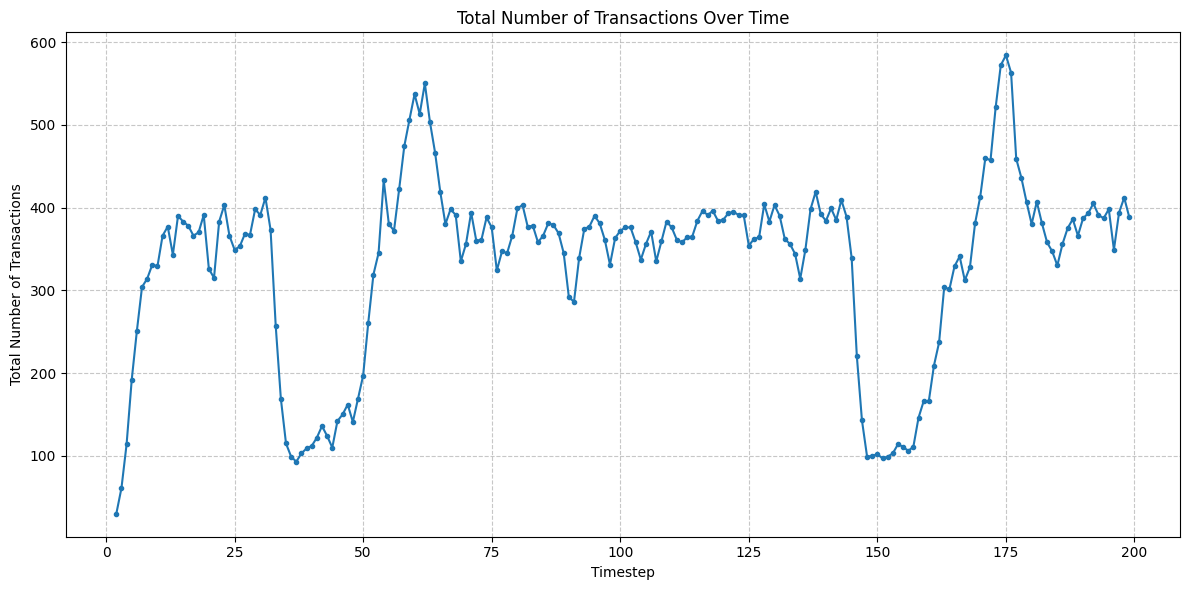

In [18]:
# plot transactions over time
plot_transactions_over_time(transactions)

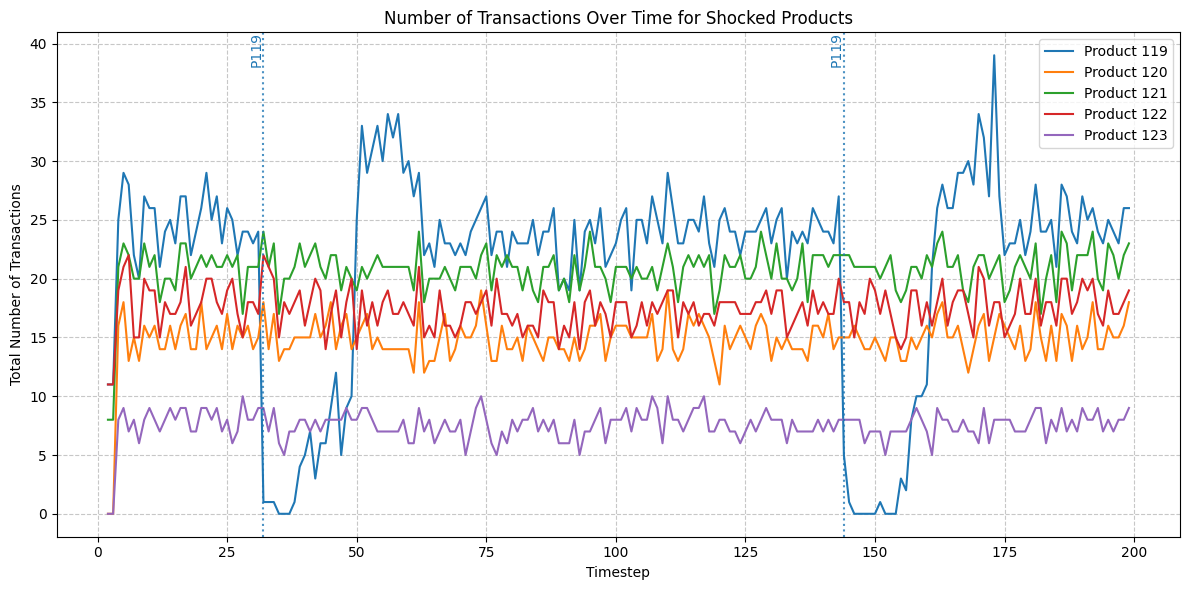

In [19]:
# given (shock time)
shock_times = {
    119: [32, 144],
    120: [],
    121: [],
    122: [], 
    123: []
}
plot_shocks_on_exogenous_supply(transactions, shock_times)

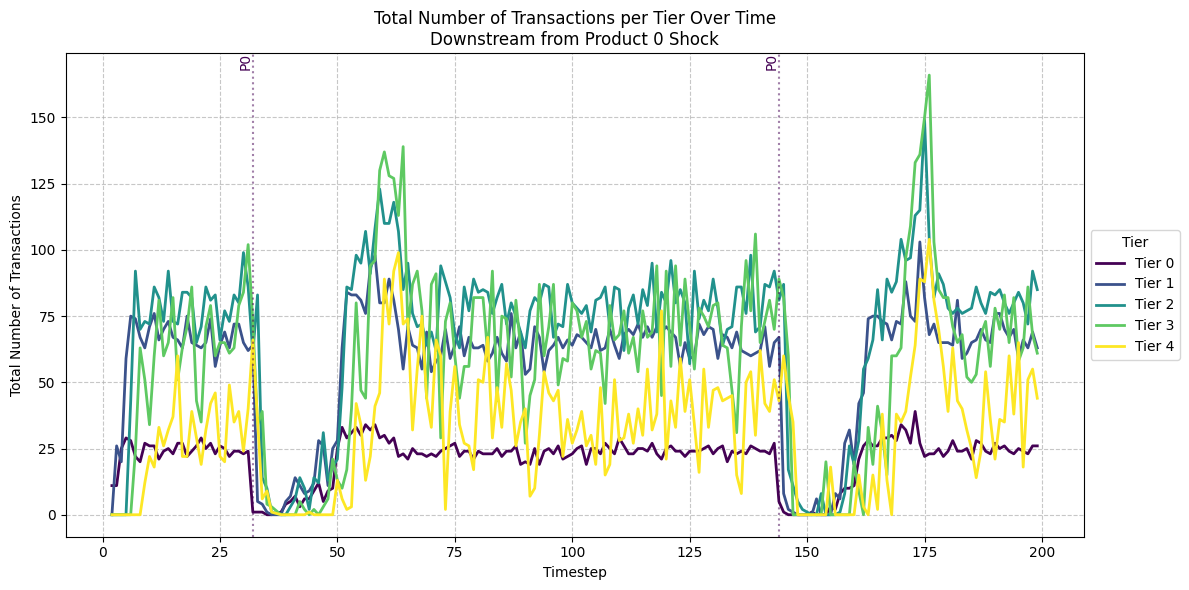

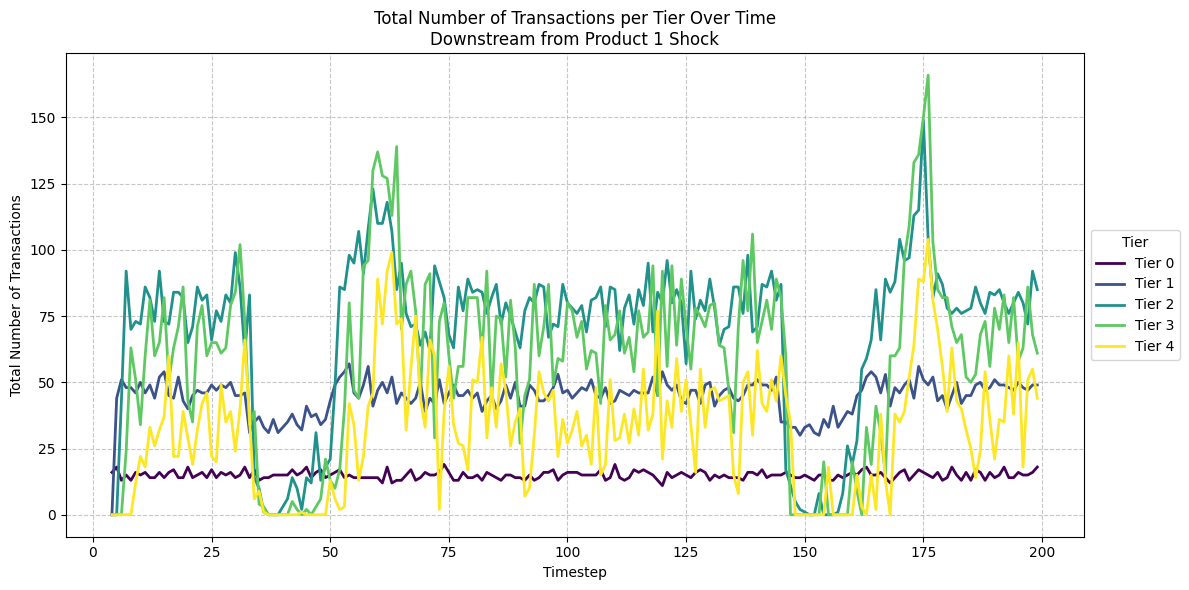

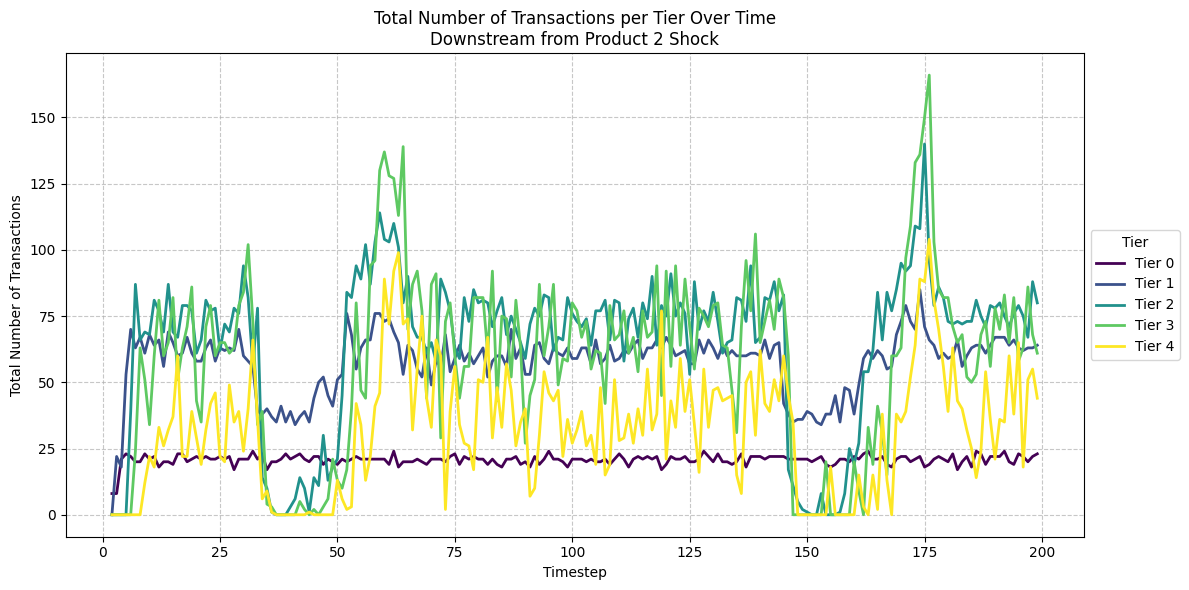

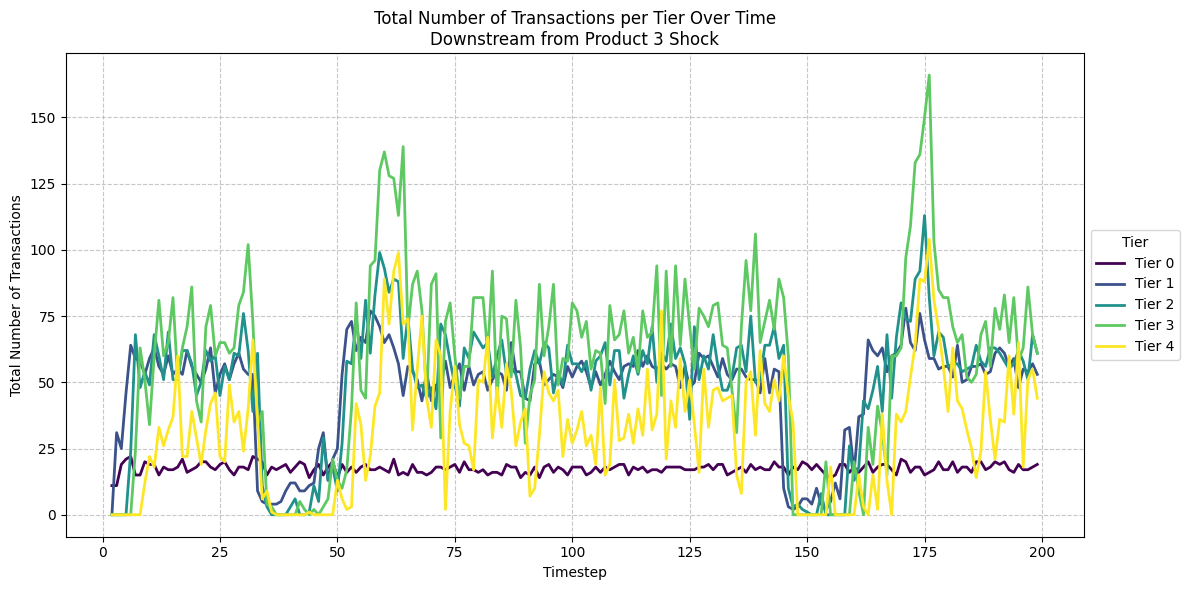

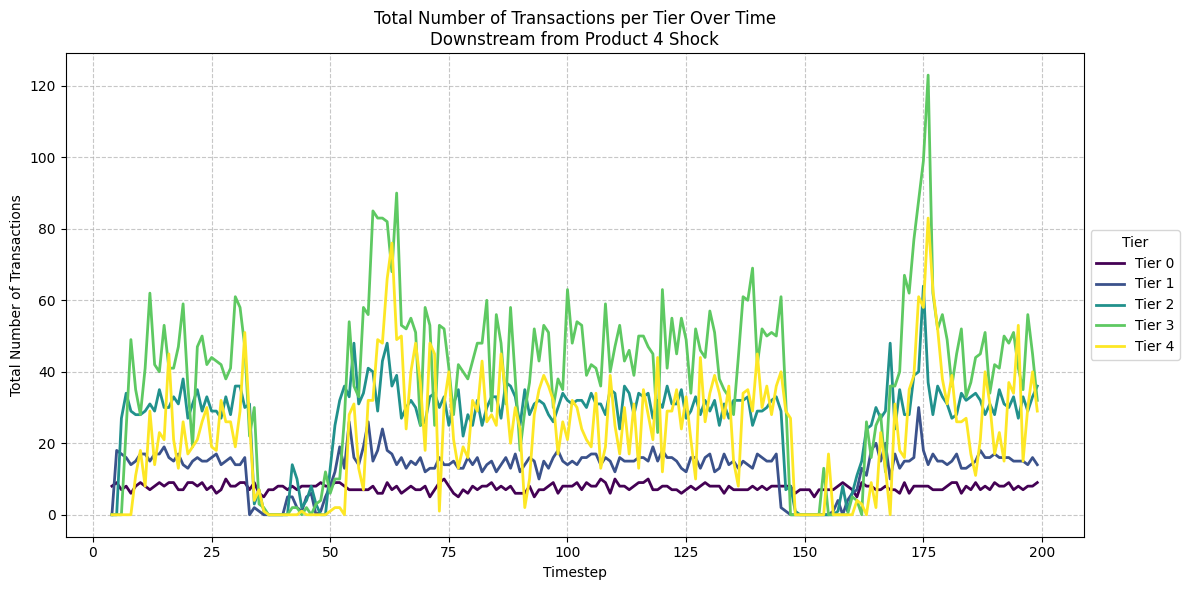

In [20]:
add_product_tiers(transactions, prod_graph)
plot_transactions_per_tier_perexogprod(transactions, prod_graph, shock_times, exog_prod_ids=[0, 1, 2, 3, 4]) 
# only exog_prod 0 experiences shock; exog_prod 1, 2, 3, 4 do not

In [21]:
# investigate how overlapped are the downstream products for each exogeneous product 
from itertools import combinations

def find_downstream_products(source_products): # input a list of source products
    if len(source_products) == 0:
        return []
    dest_products = list(prod_graph[prod_graph['source'].isin(source_products)]['dest'].unique())
    downstream_list = find_downstream_products(dest_products) + source_products
    return downstream_list

exogenous_products = ['product0', 'product1', 'product2', 'product3', 'product4']

# Find downstream products for each exogenous product
all_downstream_products = {product: find_downstream_products([product]) for product in exogenous_products}

# Analyze the overlap between downstream products lists
overlap_results = []
for p1, p2 in combinations(exogenous_products, 2):
    overlap = set(all_downstream_products[p1]).intersection(all_downstream_products[p2])
    overlap_results.append((p1, p2, len(overlap)))

print(overlap_results) # exog_prod1, exog_prod2, # overlap

[('product0', 'product1', 35), ('product0', 'product2', 37), ('product0', 'product3', 38), ('product0', 'product4', 24), ('product1', 'product2', 35), ('product1', 'product3', 32), ('product1', 'product4', 23), ('product2', 'product3', 36), ('product2', 'product4', 21), ('product3', 'product4', 20)]


# Metric
Definition. For each product at time t, whether the # of txn < 50% of its historical average (i.e. last window=10 timesteps)

Evaluate how good the metric is by

-> False positives: if i mislabel a normal to shock. To check, cross-apply on SS-std should get all negative labels

-> False negatives: if i missed a shock

Note: Ignore first 10 timesteps (warmup values)!!!

In [22]:
# calculate shock metric
def calculate_shock_metric(transactions, THRESHOLD=0.5, window=14): # note: window better be multiple of 7 
    transactions = transactions.sort_values(by=['product', 'ts'])
    grouped = transactions.groupby(by=['product', 'ts']).size().reset_index(name="num_txns")
    # note: the first 'window' timestamps have incorrect values, but it's okay because we ignore them later
    grouped["historical_avg"] = grouped["num_txns"].rolling(window=window, min_periods=1).mean()

    # map grouped historical average result back to transactions
    transactions = pd.merge(
        transactions,
        grouped[['product', 'ts', 'num_txns', 'historical_avg']],
        on=['product', 'ts'],
        how='left'
    )
    transactions['shock'] = transactions["num_txns"] < THRESHOLD * transactions["historical_avg"]
    
    # Ignore warmup period
    transactions = transactions[transactions['ts'] > window]
    
    return transactions

In [23]:
# Define hyperparameters
warmup_period = [7, 14, 21, 28, 56]
THRESHOLD = [0.2, 0.4, 0.6, 0.65, 0.7, 0.75, 0.8]

In [24]:
'''
Evaluate false positives
- That is, if one mislabels a normal transaction as shock
- We cross-apply on SS-std should get all negative labels
'''

# load in ss-std
DIR = "/lfs/local/0/serinac/supply-chains/TGB/tgb/datasets/tgbl_hypergraph_synthetic_std"
edgelist = "tgbl-hypergraph_synthetic_std_edgelist.csv"
std_data = pd.read_csv(os.path.join(DIR, edgelist))

# Create an empty list to store results
std_results = []

# Loop through hyperparameter combinations
for wp in warmup_period:
    for t in THRESHOLD:     
        # Calculate the shock metric for the given parameters
        std_transactions_metric = calculate_shock_metric(std_data, THRESHOLD=t, window=wp)
        
        # Count the number of false positives (shocks detected in steady-state data)
        num_false_positives = std_transactions_metric['shock'].sum()
        
        # Append the results as a dictionary
        std_results.append({
            'warmup_period': wp,
            'THRESHOLD': t,
            'num_transactions': std_transactions_metric.shape[0],
            'num_false_positives': num_false_positives, 
            'fasle_positive_rate': num_false_positives / std_transactions_metric.shape[0]
        })

false_positive_df = pd.DataFrame(std_results) # dataframe stores result

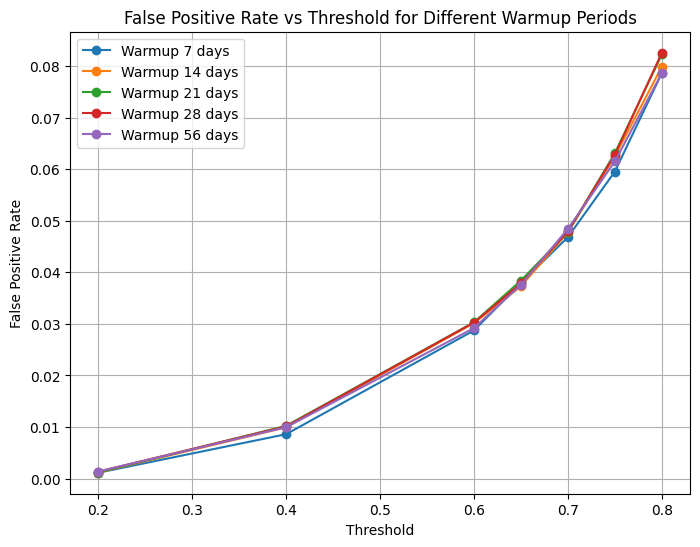

In [25]:
# visualize hyperparameter effect on false positive rate
def visualize_false_positive(df):
    # Plot
    plt.figure(figsize=(8,6))
    
    # Plot each warmup period with a different color
    for period in df['warmup_period'].unique():
        subset = df[df['warmup_period'] == period]
        plt.plot(subset.THRESHOLD, subset.fasle_positive_rate, marker='o', label=f'Warmup {period} days')
    
    # Add labels and title
    plt.xlabel('Threshold')
    plt.ylabel('False Positive Rate')
    plt.title('False Positive Rate vs Threshold for Different Warmup Periods')
    plt.legend()
    plt.grid(True)
    plt.show()
visualize_false_positive(false_positive_df)

In [26]:
# visualize ss-std 
# add_product_tiers(std_data, prod_graph)
# plot_transactions_per_tier_perexogprod(std_data, prod_graph, {}, [0, 1, 2, 3, 4])

In [27]:
# Objects to be used for evaluating false negatives
print(prod_graph.head(), prod_graph.shape)
print(shock_times)
print(transactions.shape)

     source      dest  units  layer
0  product1  product5      3      1
1  product4  product5      4      1
2  product0  product5      3      1
3  product3  product6      4      1
4  product0  product6      2      1 (133, 4)
{119: [32, 144], 120: [], 121: [], 122: [], 123: []}
(65814, 6)


In [28]:
'''
Evaluate false negatives
- That is, if one misses a shock transaction in ss-shock
- For each shock, we define [t + tier, t + tier + 3] as shock period for the exogeneous product and the downstream products
'''
# Define hyperparameters
shock_durations = [3, 7, 14]
def generate_shock_mapping(prod_graph, shock_times, shock_duration=7):
    shock_mapping = defaultdict(list)
    max_layer = prod_graph['layer'].max()

    # Initialize shock propagation for given shock times
    for product, times in shock_times.items():
        product = f"product{product - PROD_OFFSET}"
        for shock_time in times:
            shock_mapping[product].extend([shock_time + d for d in range(shock_duration)])

    # Propagate shocks through the layers
    for layer in range(1, max_layer + 1):
        layer_products = prod_graph[prod_graph['layer'] == layer]
        for _, row in layer_products.iterrows():
            dest_product = row['dest']
            source_products = prod_graph[(prod_graph['dest'] == dest_product) & (prod_graph['layer'] == layer)]['source']
            
            for source_product in source_products:
                if source_product in shock_mapping:
                    for shock_time in shock_mapping[source_product]:
                        propagated_time = shock_time + 1  # Add 1 for each layer of propagation
                        shock_mapping[dest_product].extend([propagated_time])
    
    # Remove duplicates and sort shock times for each product
    mapping = {}
    for product in shock_mapping:
        key = int(product.replace('product', '')) + PROD_OFFSET
        value = set(shock_mapping[product])
        mapping[key] = value
    
    return mapping

def is_true_shock(row, shock_mapping):
    product = row['product']
    ts = row['ts']
    if product in shock_mapping:
        return ts in shock_mapping[product]
    return False

shock_results = []
# Loop through hyperparameter combinations
for dur in shock_durations:
    shock_mapping = generate_shock_mapping(prod_graph, shock_times, dur) # prod -> times of shock
    for wp in warmup_period:
        for t in THRESHOLD:     
            # Calculate the shock metric for the given parameters
            shock_transactions_metric = calculate_shock_metric(transactions, THRESHOLD=t, window=wp)
            
            # Count the number of false negatives (shocks not detected in shock-state data)
            shock_transactions_metric['true_shock'] = shock_transactions_metric.apply(lambda row: is_true_shock(row, shock_mapping), axis=1)
            num_false_negatives = ((shock_transactions_metric['shock'] == False) 
                                   & (shock_transactions_metric['true_shock'] == True)).sum() # i.e. our prediction missed a true shock
            
            # Append the results as a dictionary
            shock_results.append({
                'warmup_period': wp,
                'THRESHOLD': t,
                f'num_shocks_dur{dur}': shock_transactions_metric.true_shock.sum(),
                f'num_false_negatives_dur{dur}': num_false_negatives,
                f'fasle_negative_rate_dur{dur}': num_false_negatives / shock_transactions_metric.true_shock.sum()
            })

false_negative_df = pd.DataFrame(shock_results)

/tmp/user/22018/ipykernel_268856/3448449172.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(warmup_periods))


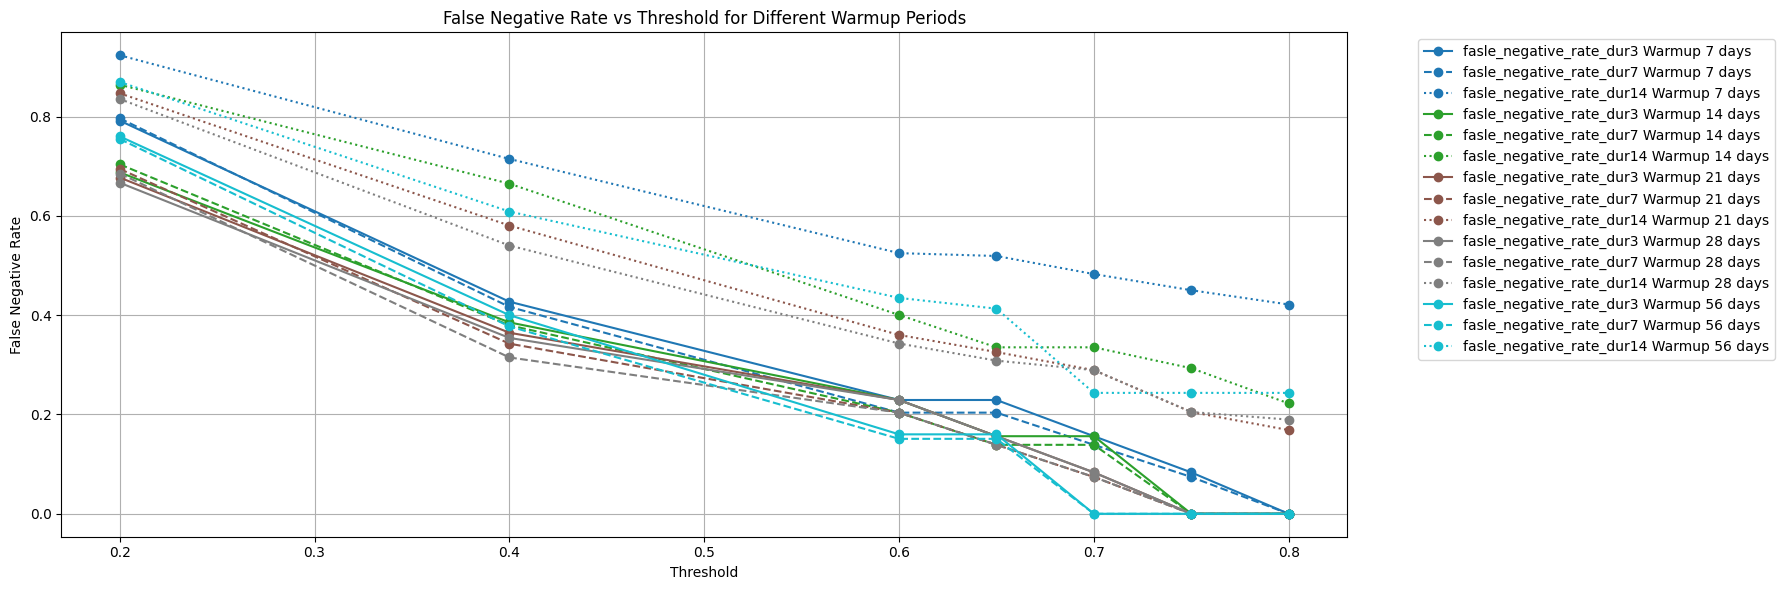

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Function to visualize false negative rates for different durations
def visualize_false_negative(df):
    durations = ['fasle_negative_rate_dur3', 'fasle_negative_rate_dur7', 'fasle_negative_rate_dur14']
    warmup_periods = df['warmup_period'].unique()
    
    # Generate a color map for warmup periods
    colors = cm.get_cmap('tab10', len(warmup_periods))
    
    plt.figure(figsize=(18, 6))
    
    for i, period in enumerate(warmup_periods):
        subset = df[df['warmup_period'] == period]
        for j, duration in enumerate(durations):
            linestyle = ['solid', 'dashed', 'dotted'][j]  # Different line styles for each duration
            plt.plot(subset['THRESHOLD'], subset[duration], 
                     marker='o', 
                     label=f'{duration} Warmup {period} days', 
                     color=colors(i), 
                     linestyle=linestyle)
    
    # Add labels and title
    plt.xlabel('Threshold')
    plt.ylabel('False Negative Rate')
    plt.title('False Negative Rate vs Threshold for Different Warmup Periods')
    
    # Place legend on the side
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

# Visualize the false negative rates
visualize_false_negative(false_negative_df)

# No longer needed!
# Investigate: High False Negative Rate of Our Historical-Average Metric
Not any more! Once we replaced the metric's source-product-level historical averages with product-level historical averages

In [ ]:
# Isolate out a single case
dur = 7
wp = 7
t = 0.6

shock_transactions_metric = calculate_shock_metric(transactions, THRESHOLD=t, window=wp)
shock_mapping = generate_shock_mapping(prod_graph, shock_times, dur) # prod -> times of shock
 # Count the number of false negatives (shocks not detected in shock-state data)
shock_transactions_metric['true_shock'] = shock_transactions_metric.apply(lambda row: is_true_shock(row, shock_mapping), axis=1)
num_false_negatives = ((shock_transactions_metric['shock'] == False) 
                       & (shock_transactions_metric['true_shock'] == True)).sum() # i.e. our prediction missed a true shock
# Append the results as a dictionary
shock_results = {
    'warmup_period': wp,
    'THRESHOLD': t,
    f'num_shocks_dur{dur}': shock_transactions_metric.true_shock.sum(),
    f'num_false_negatives_dur{dur}': num_false_negatives,
    f'fasle_negative_rate_dur{dur}': num_false_negatives / shock_transactions_metric.true_shock.sum()
}
shock_results

In [ ]:
# only get downstream products of product 0, since these are the potential places where false negatives might show up
def find_downstream_products(source_products): # input a list of source products
    if len(source_products) == 0:
        return []
    dest_products = list(prod_graph[prod_graph['source'].isin(source_products)]['dest'].unique())
    downstream_list = find_downstream_products(dest_products) + source_products
    return downstream_list

downstream_products_of_0 = [int(prod.replace("product", "")) + PROD_OFFSET for prod in find_downstream_products(['product0'])]
shock_transactions_metric = shock_transactions_metric[shock_transactions_metric["product"].isin(downstream_products_of_0)]

In [ ]:
# check tier 0 data -> this is an easy task, our historical average metric should not fail! 
# indeed, our metric succeeded
tier0_data = shock_transactions_metric[shock_transactions_metric["tier"]==0]

print("# true positive", 
      tier0_data[(shock_transactions_metric['shock'] == True) & (shock_transactions_metric['true_shock'] == True)].shape[0])

print("# false negative", 
      tier0_data[(shock_transactions_metric['shock'] == False) & (shock_transactions_metric['true_shock'] == True)].shape[0])

In [ ]:
# print # of true positives, # of false negatives per tier
for tier in range(6):
    tier_data = shock_transactions_metric[shock_transactions_metric["tier"]==tier]
    true_positive = tier_data[(shock_transactions_metric['shock'] == True) & (shock_transactions_metric['true_shock'] == True)]
    false_negative = tier_data[(shock_transactions_metric['shock'] == False) & (shock_transactions_metric['true_shock'] == True)]
    print(f"Tier {tier}: # true positive {true_positive.shape[0]} and # false negative {false_negative.shape[0]}")

In [ ]:
# check tier 2 data
tier2_data = shock_transactions_metric[shock_transactions_metric["tier"]==2]
true_positive = tier2_data[(shock_transactions_metric['shock'] == True) & (shock_transactions_metric['true_shock'] == True)]
false_negative = tier2_data[(shock_transactions_metric['shock'] == False) & (shock_transactions_metric['true_shock'] == True)]

In [ ]:
true_positive

In [ ]:
# cross check with the per-product plot above to see why these transactions are false negatives
false_negative

In [ ]:
# Plotting
groupby = shock_transactions_metric.groupby(["ts", "product"]).sum().reset_index()

prods_to_plot = false_negative["product"].unique() # groupby['product'].unique()
# note: summing historical average is not statistically valid, but it is (hopefully) approximately proportional to the true historical sum
for prod in prods_to_plot:
    prod_data = groupby[groupby['product'] == prod]
    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    # Plot historical average and num_txns
    axs[0].plot(prod_data['ts'], prod_data['historical_avg'], label=f'Product {prod} Hist', color='blue')
    axs[0].plot(prod_data['ts'], prod_data['num_txns'], label=f'Product {prod} True', color='orange')
    axs[0].set_title(f'Actual Transactions vs Historical Average for Product {prod}')
    axs[0].set_ylabel('Number of Transactions (Sum)')
    axs[0].legend()
    axs[0].grid(True)
    
    # Highlight true_shock and shock
    axs[1].scatter(prod_data['ts'], 
                prod_data['shock'], 
                color='green', label='Hist Shock')
    
    axs[1].scatter(prod_data['ts'],
                prod_data['true_shock'], 
                color='red', label='True Shock')
    axs[1].set_title(f'True Shock vs Historical-Averaged Shock for Product {prod}')
    axs[1].set_ylabel('Number of Shock Transactions Identified')
    axs[1].legend()
    axs[1].grid(True)

    # Set common x-label
    axs[-1].set_xlabel('Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()